<a href="https://colab.research.google.com/github/Minal-2007/PROJECTS-/blob/main/OrbitGuard_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


In [133]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',10)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [134]:
df=pd.read_csv("/content/space_debris_dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [135]:
df.head()

,Type,Object_Name,Orbit_Class,Apogee_km,Perigee_km,Inclination_deg,Source_Country,Eccentricity,Semi_Major_Axis_km,Period_minutes,Mean_Motion,Speed_km_s,RCS_m2,Launch_Date,Launch_Year,Decay_Risk,Object_ID
0,PAYLOAD,Starlink-Like 4678,LEO,548.598432,544.201241,52.955717,USA,0.000318,6917.399837,95.427610,15.089972,7.593386,0.571893,2022-04-04,2022,0.017564,SAT_00000
1,PAYLOAD,Starlink-Like 3370,LEO,541.338345,534.534652,53.003450,USA,0.000492,6908.936498,95.252533,15.117708,7.599362,4.589595,2020-01-24,2020,0.143520,SAT_00001
2,PAYLOAD,Starlink-Like 5342,LEO,562.608138,558.528933,52.819489,USA,0.000294,6931.568535,95.720953,15.043728,7.585442,0.195672,2025-11-23,2025,0.005854,SAT_00002
3,PAYLOAD,OneWeb-Like 8011,LEO,1191.535905,1188.680264,87.814904,EU,0.000189,7561.108084,109.053071,13.204580,7.262032,2.262243,2024-09-05,2024,0.031810,SAT_00003
4,PAYLOAD,Starlink-Like 9952,LEO,554.032018,551.577592,52.999758,USA,0.000177,6923.804805,95.560179,15.069038,7.588806,0.768526,2014-09-14,2014,0.023288,SAT_00004


In [136]:
df.tail()

,Type,Object_Name,Orbit_Class,Apogee_km,Perigee_km,Inclination_deg,Source_Country,Eccentricity,Semi_Major_Axis_km,Period_minutes,Mean_Motion,Speed_km_s,RCS_m2,Launch_Date,Launch_Year,Decay_Risk,Object_ID
4995,PAYLOAD,OneWeb-Like 2955,LEO,1204.958633,1200.238625,87.873536,EU,0.000312,7573.598629,109.323407,13.171928,7.256932,2.743838,2017-04-14,2017,0.038211,SAT_04995
4996,PAYLOAD,Starlink-Like 4021,LEO,555.648812,553.702768,53.009326,USA,0.000140,6925.675790,95.598916,15.062932,7.587502,3.464637,2019-06-12,2019,0.104591,SAT_04996
4997,PAYLOAD,PAYLOAD_51490,LEO,224.789948,224.189400,24.517231,USA,0.000046,6595.489674,88.844449,16.208103,7.774369,4.165193,2021-04-02,2021,0.310554,SAT_04997
4998,PAYLOAD,Starlink-Like 1277,LEO,557.207811,551.632702,52.919384,USA,0.000403,6925.420256,95.593625,15.063766,7.589630,0.747789,2025-05-02,2025,0.022657,SAT_04998
4999,DEBRIS,DEBRIS_65820,LEO,802.023944,800.782277,99.487473,RUSSIA,0.000087,7172.403111,100.752717,14.292419,7.455455,0.210821,2010-03-03,2010,0.004399,SAT_04999


In [137]:
print("Number of Rows :",df.shape[0])
print("Number of Columns :",df.shape[1])

Number of Rows : 5000
Number of Columns : 17


In [138]:
print(df.columns)

Index(['Type', 'Object_Name', 'Orbit_Class', 'Apogee_km', 'Perigee_km',
       'Inclination_deg', 'Source_Country', 'Eccentricity',
       'Semi_Major_Axis_km', 'Period_minutes', 'Mean_Motion', 'Speed_km_s',
       'RCS_m2', 'Launch_Date', 'Launch_Year', 'Decay_Risk', 'Object_ID'],
      dtype='object')


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Type                5000 non-null   object 
 1   Object_Name         5000 non-null   object 
 2   Orbit_Class         5000 non-null   object 
 3   Apogee_km           5000 non-null   float64
 4   Perigee_km          5000 non-null   float64
 5   Inclination_deg     5000 non-null   float64
 6   Source_Country      5000 non-null   object 
 7   Eccentricity        5000 non-null   float64
 8   Semi_Major_Axis_km  5000 non-null   float64
 9   Period_minutes      5000 non-null   float64
 10  Mean_Motion         5000 non-null   float64
 11  Speed_km_s          5000 non-null   float64
 12  RCS_m2              5000 non-null   float64
 13  Launch_Date         5000 non-null   object 
 14  Launch_Year         5000 non-null   int64  
 15  Decay_Risk          5000 non-null   float64
 16  Object

In [140]:
df.describe()

,Apogee_km,Perigee_km,Inclination_deg,Eccentricity,Semi_Major_Axis_km,Period_minutes,Mean_Motion,Speed_km_s,RCS_m2,Launch_Year,Decay_Risk
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2933.806336,2369.688527,60.086708,1.081696e-02,9022.747431,167.335877,13.693831,7.301707,1.684178,2020.080000,0.043241
std,8091.650214,6757.090810,20.214767,8.529518e-02,7105.935252,256.415991,3.600057,1.033221,2.666341,6.380858,0.072766
min,217.635872,217.611702,0.003270,3.065109e-07,6588.625582,88.705791,1.002814,3.074912,0.004119,1957.000000,0.000000
25%,548.605922,545.541640,52.931152,1.334099e-04,6918.112710,95.442362,14.212793,7.455284,0.330988,2018.000000,0.007313
50%,554.317140,551.105583,53.039756,2.313849e-04,6923.683844,95.557675,15.069433,7.589359,0.827737,2022.000000,0.020205
75%,832.723268,822.310868,63.448629,3.865805e-04,7199.166682,101.317175,15.087640,7.592598,1.835611,2025.000000,0.047624
max,39980.168814,35786.835286,101.025714,7.314316e-01,42162.022741,1435.958495,16.233438,9.806968,43.589713,2026.000000,1.000000


In [141]:
missing = df.isnull().sum()

In [142]:
print(missing)

Type           0
Object_Name    0
Orbit_Class    0
Apogee_km      0
Perigee_km     0
              ..
RCS_m2         0
Launch_Date    0
Launch_Year    0
Decay_Risk     0
Object_ID      0
Length: 17, dtype: int64


In [143]:
duplicates = df.duplicated().sum()

In [144]:
print("Duplicated Rows :",duplicates)

Duplicated Rows : 0


In [145]:
df.sample(10)

,Type,Object_Name,Orbit_Class,Apogee_km,Perigee_km,Inclination_deg,Source_Country,Eccentricity,Semi_Major_Axis_km,Period_minutes,Mean_Motion,Speed_km_s,RCS_m2,Launch_Date,Launch_Year,Decay_Risk,Object_ID
1682,PAYLOAD,Starlink-Like 3718,LEO,552.986057,550.378231,52.903924,USA,0.000188,6922.682144,95.536938,15.072704,7.589506,1.489113,2025-08-08,2025,0.045224,SAT_01682
4804,PAYLOAD,Starlink-Like 7171,LEO,551.721075,550.350149,52.961506,USA,0.000099,6922.035612,95.523554,15.074816,7.589182,1.115869,2021-12-30,2021,0.033890,SAT_04804
4604,PAYLOAD,Starlink-Like 9250,LEO,550.708590,548.655838,52.908872,USA,0.000148,6920.682214,95.495541,15.079238,7.590298,1.000443,2025-12-03,2025,0.030478,SAT_04604
4700,PAYLOAD,OneWeb-Like 7918,LEO,1203.295358,1200.522902,87.901375,EU,0.000183,7572.909130,109.308478,13.173727,7.256330,1.740220,2021-08-23,2021,0.024228,SAT_04700
3591,PAYLOAD,Starlink-Like 9133,LEO,552.204129,547.620369,53.010083,USA,0.000331,6920.912249,95.500302,15.078486,7.591560,1.230152,2026-12-13,2026,0.037547,SAT_03591
3329,PAYLOAD,Starlink-Like 2586,LEO,546.350098,544.326445,53.063334,USA,0.000146,6916.338272,95.405644,15.093447,7.592666,2.214816,2013-01-25,2013,0.068012,SAT_03329
2896,PAYLOAD,Starlink-Like 3338,LEO,552.351887,550.867666,52.936028,USA,0.000107,6922.609776,95.535440,15.072941,7.588930,0.427322,2022-08-21,2022,0.012965,SAT_02896
2368,PAYLOAD,Starlink-Like 4124,LEO,553.032992,550.173853,53.097115,USA,0.000207,6922.603423,95.535308,15.072961,7.589687,4.750284,2018-04-04,2018,0.144322,SAT_02368
4205,DEBRIS,DEBRIS_76814,LEO,713.118042,699.765357,97.078550,RUSSIA,0.000943,7077.441700,98.758431,14.581034,7.511738,0.449811,2010-11-28,2010,0.010743,SAT_04205
561,PAYLOAD,Starlink-Like 1443,LEO,552.170133,547.340071,52.993254,USA,0.000349,6920.755102,95.497049,15.079000,7.591781,0.280907,2023-11-05,2023,0.008577,SAT_00561


In [146]:
for col in df.columns:
  print(f"{col} : {df[col].nunique()}")

Type : 3
Object_Name : 4507
Orbit_Class : 4
Apogee_km : 5000
Perigee_km : 5000
Inclination_deg : 5000
Source_Country : 7
Eccentricity : 5000
Semi_Major_Axis_km : 5000
Period_minutes : 5000
Mean_Motion : 5000
Speed_km_s : 5000
RCS_m2 : 5000
Launch_Date : 3256
Launch_Year : 47
Decay_Risk : 5000
Object_ID : 5000


In [147]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

summary

,Column,Data Type,Missing Values,Unique Values
0,Type,object,0,3
1,Object_Name,object,0,4507
2,Orbit_Class,object,0,4
3,Apogee_km,float64,0,5000
4,Perigee_km,float64,0,5000
...,...,...,...,...
12,RCS_m2,float64,0,5000
13,Launch_Date,object,0,3256
14,Launch_Year,int64,0,47
15,Decay_Risk,float64,0,5000


In [148]:
eda_df = df.copy()

In [149]:
import plotly.express as px

fig = px.bar(
    eda_df["Type"].value_counts().reset_index(),
    x="Type",
    y="count",
    color="Type",
    title="Distribution of Space Object Types",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Object Type",
    yaxis_title="Count",
    template="plotly_white"
)

fig.show()

In [150]:
fig = px.pie(
    eda_df,
    names="Orbit_Class",
    title="Distribution of Orbit Classes",
    hole=0.4
)

fig.show()

In [151]:
country_counts = eda_df["Source_Country"].value_counts()

fig = px.bar(
    country_counts,
    x=country_counts.index,
    y=country_counts.values,
    color=country_counts.index,
    text_auto=True,
    title="Objects by Source Country"
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Number of Objects",
    showlegend=False
)

fig.show()

In [152]:
fig = px.histogram(
    eda_df,
    x="Speed_km_s",
    nbins=40,
    title="Distribution of Orbital Speed"
)

fig.show()

In [153]:
fig = px.histogram(
    eda_df,
    x="Inclination_deg",
    nbins=40,
    title="Distribution of Orbital Inclination"
)

fig.show()

In [154]:
launch_year = (
    eda_df["Launch_Year"]
    .value_counts()
    .sort_index()
)

fig = px.line(
    x=launch_year.index,
    y=launch_year.values,
    markers=True,
    title="Objects Launched Per Year"
)

fig.update_layout(
    xaxis_title="Launch Year",
    yaxis_title="Number of Objects"
)

fig.show()

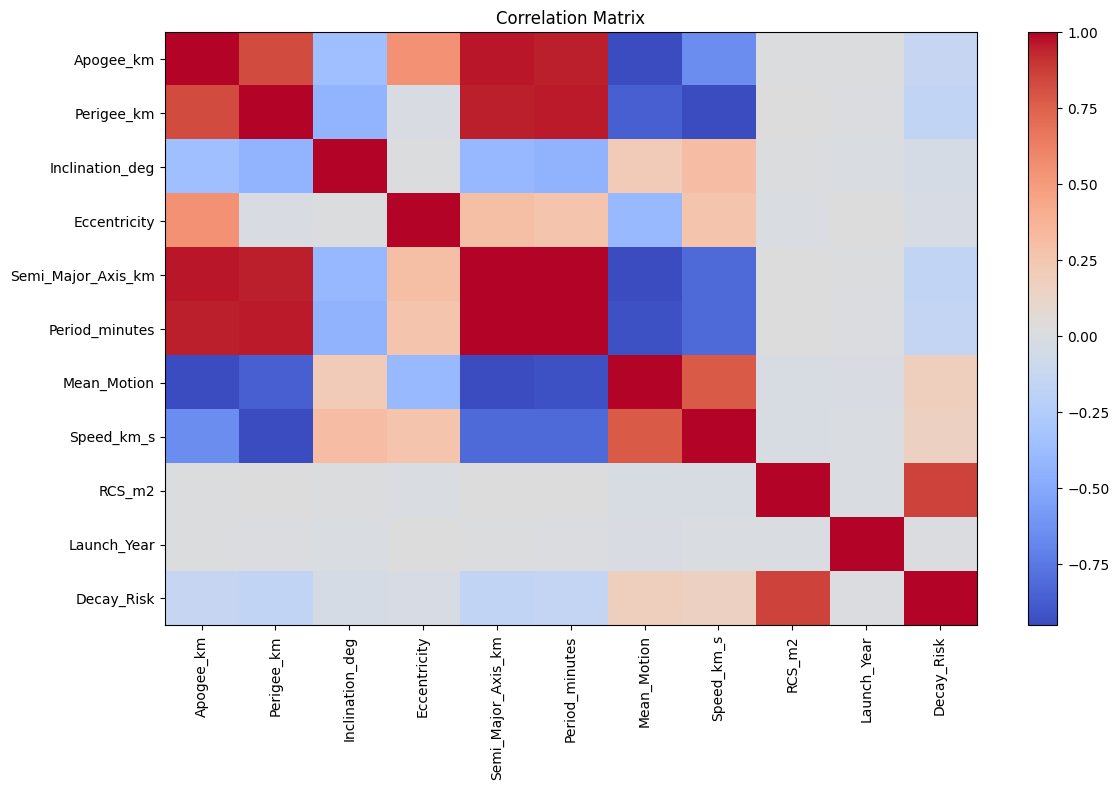

In [155]:
import matplotlib.pyplot as plt

corr = eda_df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [156]:
numerical_columns = [
    "Apogee_km",
    "Perigee_km",
    "Speed_km_s",
    "Inclination_deg",
    "RCS_m2"
]

for column in numerical_columns:

    fig = px.box(
        eda_df,
        y=column,
        title=f"Boxplot of {column}"
    )

    fig.show()

In [157]:
feature_df = eda_df.copy()

print("Feature Engineering Started!")

Feature Engineering Started!


In [158]:
feature_df["Average_Altitude"] = (
    feature_df["Apogee_km"] +
    feature_df["Perigee_km"]
) / 2

feature_df[["Apogee_km","Perigee_km","Average_Altitude"]].head()

,Apogee_km,Perigee_km,Average_Altitude
0,548.598432,544.201241,546.399837
1,541.338345,534.534652,537.936498
2,562.608138,558.528933,560.568535
3,1191.535905,1188.680264,1190.108084
4,554.032018,551.577592,552.804805


In [159]:
CURRENT_YEAR = 2026

feature_df["Orbit_Age"] = (
    CURRENT_YEAR -
    feature_df["Launch_Year"]
)

feature_df[["Launch_Year","Orbit_Age"]].head()

,Launch_Year,Orbit_Age
0,2022,4
1,2020,6
2,2025,1
3,2024,2
4,2014,12


In [160]:
feature_df["Altitude_Range"] = (
    feature_df["Apogee_km"] -
    feature_df["Perigee_km"]
)

feature_df[["Apogee_km","Perigee_km","Altitude_Range"]].head()

,Apogee_km,Perigee_km,Altitude_Range
0,548.598432,544.201241,4.397190
1,541.338345,534.534652,6.803693
2,562.608138,558.528933,4.079205
3,1191.535905,1188.680264,2.855640
4,554.032018,551.577592,2.454426


In [161]:
def classify_rcs(rcs):

    if rcs < 1:
        return "Small"

    elif rcs < 5:
        return "Medium"

    else:
        return "Large"


feature_df["RCS_Category"] = (
    feature_df["RCS_m2"]
    .apply(classify_rcs)
)

feature_df[["RCS_m2","RCS_Category"]].head()

,RCS_m2,RCS_Category
0,0.571893,Small
1,4.589595,Medium
2,0.195672,Small
3,2.262243,Medium
4,0.768526,Small


In [162]:
def classify_speed(speed):

    if speed < 5:
        return "Low"

    elif speed < 8:
        return "Medium"

    else:
        return "High"


feature_df["Speed_Category"] = (
    feature_df["Speed_km_s"]
    .apply(classify_speed)
)

feature_df[["Speed_km_s","Speed_Category"]].head()

,Speed_km_s,Speed_Category
0,7.593386,Medium
1,7.599362,Medium
2,7.585442,Medium
3,7.262032,Medium
4,7.588806,Medium


In [163]:
feature_df["Norm_Decay"] = feature_df["Decay_Risk"]

feature_df["Norm_Age"] = (
    feature_df["Orbit_Age"] /
    feature_df["Orbit_Age"].max()
)

feature_df["Norm_Altitude_Range"] = (
    feature_df["Altitude_Range"] /
    feature_df["Altitude_Range"].max()
)

feature_df["Norm_Speed"] = (
    feature_df["Speed_km_s"] /
    feature_df["Speed_km_s"].max()
)

In [164]:
type_score = {
    "PAYLOAD":0.2,
    "ROCKET BODY":0.6,
    "DEBRIS":1.0
}

feature_df["Type_Score"] = (
    feature_df["Type"]
    .map(type_score)
)

In [165]:
feature_df["ORI"] = (

      0.35*feature_df["Norm_Decay"]

    + 0.20*feature_df["Norm_Age"]

    + 0.15*feature_df["Norm_Altitude_Range"]

    + 0.15*feature_df["Norm_Speed"]

    + 0.15*feature_df["Type_Score"]

)

In [166]:
def classify_risk(score):

    if score < 0.30:
        return "Low"

    elif score < 0.60:
        return "Medium"

    else:
        return "High"


feature_df["Risk_Level"] = (
    feature_df["ORI"]
    .apply(classify_risk)
)

feature_df[["ORI","Risk_Level"]].head()

,ORI,Risk_Level
0,0.163901,Low
1,0.213884,Low
2,0.150984,Low
3,0.158016,Low
4,0.189016,Low


In [167]:
import plotly.express as px

fig = px.bar(
    feature_df["Risk_Level"].value_counts().reset_index(),
    x="Risk_Level",
    y="count",
    color="Risk_Level",
    text_auto=True,
    title="Distribution of Orbital Risk Levels"
)

fig.show()

In [168]:
# Remove old ORI related columns if they exist

columns_to_remove = [
    "Norm_Decay",
    "Norm_Age",
    "Norm_Altitude_Range",
    "Norm_Speed",
    "Type_Score",
    "ORI",
    "Risk_Level"
]

feature_df.drop(
    columns=[col for col in columns_to_remove if col in feature_df.columns],
    inplace=True
)

print("Old ORI columns removed.")

Old ORI columns removed.


In [169]:
feature_df["Average_Altitude"] = (
    feature_df["Apogee_km"] +
    feature_df["Perigee_km"]
)/2

In [170]:
CURRENT_YEAR = 2026

feature_df["Orbit_Age"] = (
    CURRENT_YEAR -
    feature_df["Launch_Year"]
)

In [171]:
feature_df["Altitude_Range"] = (
    feature_df["Apogee_km"] -
    feature_df["Perigee_km"]
)

In [172]:
feature_df["Circularity_Index"] = (
    feature_df["Perigee_km"] /
    feature_df["Apogee_km"]
)

In [173]:
feature_df["RCS_Category"] = pd.cut(

    feature_df["RCS_m2"],

    bins=[0,1,5,100],

    labels=["Small","Medium","Large"]

)

In [174]:
feature_df["Age_Score"] = feature_df["Orbit_Age"].rank(pct=True)

feature_df["Decay_Score"] = feature_df["Decay_Risk"].rank(pct=True)

feature_df["Altitude_Score"] = feature_df["Average_Altitude"].rank(pct=True)

feature_df["Eccentricity_Score"] = feature_df["Eccentricity"].rank(pct=True)

feature_df["RCS_Score"] = feature_df["RCS_m2"].rank(pct=True)

In [175]:
type_map = {

    "PAYLOAD":0.20,

    "ROCKET BODY":0.75,

    "DEBRIS":1.00

}

feature_df["Type_Score"] = (
    feature_df["Type"]
    .map(type_map)
)

In [176]:
feature_df["Risk_Score"] = (

      0.25*feature_df["Decay_Score"]

    + 0.20*feature_df["Age_Score"]

    + 0.15*feature_df["Type_Score"]

    + 0.15*feature_df["Eccentricity_Score"]

    + 0.15*feature_df["RCS_Score"]

    + 0.10*feature_df["Altitude_Score"]

)

In [177]:
feature_df["Risk_Level"] = pd.qcut(

    feature_df["Risk_Score"],

    q=3,

    labels=["Low","Medium","High"]

)

In [178]:
print(feature_df["Risk_Level"].value_counts())

import plotly.express as px

fig = px.bar(

    feature_df["Risk_Level"].value_counts().reset_index(),

    x="Risk_Level",

    y="count",

    color="Risk_Level",

    text_auto=True,

    title="Balanced Orbital Risk Levels"

)

fig.show()

Risk_Level
Low       1596
High      1596
Medium    1595
Name: count, dtype: int64


In [179]:
selected_features = [

    "Type",

    "Orbit_Class",

    "Apogee_km",

    "Perigee_km",

    "Average_Altitude",

    "Altitude_Range",

    "Inclination_deg",

    "Source_Country",

    "Eccentricity",

    "Semi_Major_Axis_km",

    "Period_minutes",

    "Mean_Motion",

    "Speed_km_s",

    "RCS_m2",

    "Orbit_Age",

    "Decay_Risk",

    "Circularity_Index"

]

# Before defining X and y, handle any NaN values in Risk_Level
# This ensures LabelEncoder doesn't encounter NaN, which causes the TypeError in classification_report.
feature_df_filtered = feature_df.dropna(subset=["Risk_Level"]).copy()

X = feature_df_filtered[selected_features].copy() # Ensure X is an explicit copy
y = feature_df_filtered["Risk_Level"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (4787, 17)
Target Shape : (4787,)


In [180]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported if not already

label_encoders = {}

categorical_columns = [

    "Type",

    "Orbit_Class",

    "Source_Country"

]

for col in categorical_columns:

    encoder = LabelEncoder()

    # Integer encode and explicitly create a new Series with int64 dtype, then assign
    X[col] = pd.Series(encoder.fit_transform(X[col]), index=X.index, dtype='int64')

    label_encoders[col] = encoder

print("Categorical Features Encoded to Integer Dtypes Successfully!")
print("Dtypes of categorical columns in X after encoding:")
print(X[categorical_columns].dtypes)

Categorical Features Encoded to Integer Dtypes Successfully!
Dtypes of categorical columns in X after encoding:
Type              int64
Orbit_Class       int64
Source_Country    int64
dtype: object


In [181]:
target_encoder = LabelEncoder()

# The 'y' variable from cell 2V2uJwpQ7AY_ (a pandas Series) is expected here.
# The 'y_clean' variable previously mentioned was not defined in the kernel state.
# Therefore, use 'y' for fitting and transforming the LabelEncoder.
y = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['High' 'Low' 'Medium']


In [182]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import numpy to explicitly ensure array type

# Use the original feature_df_filtered["Risk_Level"] which is a pandas Categorical Series.
# Apply LabelEncoder to it to get integer representations. This ensures that 'y' for splitting is a numpy array of integers.
y_for_split = LabelEncoder().fit_transform(feature_df_filtered["Risk_Level"])

X_train, X_test, y_train, y_test = train_test_split(
    X.copy(), # Make a copy of X to prevent SettingWithCopyWarning
    y_for_split,
    test_size=0.20,
    random_state=42,
    stratify=y_for_split
)

# Explicitly ensure y_train and y_test are integer numpy arrays
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

categorical_columns = [
    "Type",
    "Orbit_Class",
    "Source_Country"
]

# Ensure X_train and X_test categorical columns are int64 (as intended for XGBoost)
for col in categorical_columns:
    X_train[col] = X_train[col].astype('int64')
    X_test[col] = X_test[col].astype('int64')

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)
print("Dtypes of categorical columns in X_train after split and casting:")
print(X_train[categorical_columns].dtypes)
print("Dtype of y_train after split:", y_train.dtype)

Training Samples : (3829, 17)
Testing Samples : (958, 17)
Dtypes of categorical columns in X_train after split and casting:
Type              int64
Orbit_Class       int64
Source_Country    int64
dtype: object
Dtype of y_train after split: int64


In [183]:
# Re-execute data splitting and feature type casting (modified in the previous turn)
# This ensures the new logic for y_train and X_train dtypes is applied.


In [184]:
# Re-execute data splitting and feature type casting
# This cell was already modified, now we execute it.


In [185]:
# Re-execute scaling as X_train and X_test might have been updated
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [186]:
X_train.head()

,Type,Orbit_Class,Apogee_km,Perigee_km,Average_Altitude,Altitude_Range,Inclination_deg,Source_Country,Eccentricity,Semi_Major_Axis_km,Period_minutes,Mean_Motion,Speed_km_s,RCS_m2,Orbit_Age,Decay_Risk,Circularity_Index
86,1,2,552.327700,545.065853,548.696776,7.261847,52.956451,6,0.000525,6919.696776,95.475145,15.082459,7.593697,0.511220,2,0.015676,0.986852
64,0,3,20481.056769,19658.242200,20069.649485,822.814569,66.244397,6,0.015560,26440.649485,713.128689,2.019271,3.943582,0.102082,4,0.000085,0.959826
2969,1,2,760.448233,758.066085,759.257159,2.382149,96.986377,0,0.000167,7130.257159,99.865969,14.419326,7.478058,3.890110,10,0.085776,0.996867
3911,1,2,1209.318678,1203.876897,1206.597788,5.441780,87.690256,1,0.000359,7577.597788,109.410009,13.161502,7.255361,0.453057,13,0.006289,0.995500
237,1,2,549.725520,546.155340,547.940430,3.570180,52.830422,6,0.000258,6918.940430,95.459492,15.084933,7.592086,6.068183,1,0.185720,0.993506


In [187]:
# Re-execute scaling as X_train and X_test might have been updated due to the previous modification.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [188]:
X_test.head()

,Type,Orbit_Class,Apogee_km,Perigee_km,Average_Altitude,Altitude_Range,Inclination_deg,Source_Country,Eccentricity,Semi_Major_Axis_km,Period_minutes,Mean_Motion,Speed_km_s,RCS_m2,Orbit_Age,Decay_Risk,Circularity_Index
3832,1,2,552.014103,551.347067,551.680585,0.667036,52.914800,6,0.000048,6922.680585,95.536906,15.072709,7.588443,0.277596,0,0.008414,0.998792
1850,0,3,20380.624495,20277.819828,20329.222161,102.804667,65.707206,6,0.001925,26700.222161,723.655792,1.989896,3.871217,0.049934,1,0.000039,0.994956
2978,1,2,547.754682,547.582598,547.668640,0.172084,52.926876,6,0.000012,6918.668640,95.453867,15.085822,7.590371,0.135067,1,0.004121,0.999686
3252,1,2,548.774217,544.319542,546.546880,4.454675,53.149714,6,0.000322,6917.546880,95.430653,15.089491,7.593337,0.614452,1,0.018867,0.991882
4009,1,2,844.759348,843.983566,844.371457,0.775781,97.611083,3,0.000054,7215.371457,101.659454,14.164939,7.432979,0.503104,25,0.009962,0.999082


In [189]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [190]:
# Re-execute RandomizedSearchCV (modified in the previous turn)
# This will run the hyperparameter tuning with the corrected data types.


In [191]:
# Re-execute RandomizedSearchCV with corrected data types
# This cell was already modified, now we execute it.


In [192]:
print('Scaling Completed!')

Scaling Completed!


In [193]:
!pip install xgboost -q

In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

In [195]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
        enable_categorical=True # Add this line to handle categorical features
    )

}

In [196]:
results = []

trained_models = {}

categorical_columns = [

    "Type",

    "Orbit_Class",

    "Source_Country"

]

for name, model in models.items():

    current_X_train = X_train.copy()
    current_X_test = X_test.copy()

    if name == "XGBoost":
        # Ensure categorical columns are explicitly 'category' dtype for XGBoost
        for col in categorical_columns:
            current_X_train[col] = current_X_train[col].astype('category')
            current_X_test[col] = current_X_test[col].astype('category')

    # Logistic Regression requires scaled data
    if name == "Logistic Regression":

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

    else:

        model.fit(current_X_train, y_train)

        predictions = model.predict(current_X_test)

    trained_models[name] = model

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.931106,0.932267,0.931106,0.931464
2,Random Forest,0.913361,0.916090,0.913361,0.914086
1,Decision Tree,0.864301,0.865965,0.864301,0.864898
0,Logistic Regression,0.741127,0.741712,0.741127,0.740666


In [197]:
import plotly.express as px

fig = px.bar(

    results_df,

    x="Model",

    y="Accuracy",

    color="Model",

    text_auto=".3f",

    title="Comparison of Machine Learning Models"

)

fig.update_layout(

    template="plotly_white"

)

fig.show()

In [198]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model :", best_model_name)

Best Model : XGBoost


In [199]:
print('Best Model :', best_model_name)

Best Model : XGBoost


In [200]:
from sklearn.metrics import classification_report

categorical_columns = [

    "Type",

    "Orbit_Class",

    "Source_Country"

]

# Ensure target_names is a list of strings
# This defensively converts all class names to strings,
# preventing TypeError if any unexpected non-string type appears.
safe_target_names = [str(cls) for cls in target_encoder.classes_]

if best_model_name == "Logistic Regression":

    predictions = best_model.predict(X_test_scaled)

else:
    # Prepare X_test for prediction, ensuring categorical dtypes for XGBoost if it's the best model
    if best_model_name == "XGBoost":
        X_test_for_prediction = X_test.copy()
        for col in categorical_columns:
            if col in X_test_for_prediction.columns:
                X_test_for_prediction[col] = X_test_for_prediction[col].astype('category')
        predictions = best_model.predict(X_test_for_prediction)
    else:
        predictions = best_model.predict(X_test)

print(

    classification_report(

        y_test,

        predictions,

        target_names=safe_target_names

    )

)

              precision    recall  f1-score   support

        High       0.96      0.93      0.95       320
         Low       0.96      0.94      0.95       319
      Medium       0.88      0.92      0.90       319

    accuracy                           0.93       958
   macro avg       0.93      0.93      0.93       958
weighted avg       0.93      0.93      0.93       958



In [201]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [202]:
param_grid = {

    "n_estimators": [100, 200, 300, 400],

    "max_depth": [3, 5, 7, 9],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]

}

In [203]:
xgb = XGBClassifier(

    random_state=42,

    eval_metric="mlogloss",

    enable_categorical=True # Ensure this is set for RandomizedSearchCV

)

random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [204]:
categorical_columns = [
    "Type",
    "Orbit_Class",
    "Source_Country"
]
print("Dtypes of categorical columns in X_train before random_search.fit():")
print(X_train[categorical_columns].dtypes)
print("Dtype of y_train before random_search.fit():", y_train.dtype)

random_search.fit(X_train, y_train)

Dtypes of categorical columns in X_train before random_search.fit():
Type              int64
Orbit_Class       int64
Source_Country    int64
dtype: object
Dtype of y_train before random_search.fit(): int64
Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300, 400],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [205]:
print('RandomizedSearchCV completed successfully!')
print('Best Parameters:\n')
print(random_search.best_params_)

RandomizedSearchCV completed successfully!
Best Parameters:

{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [206]:
print('RandomizedSearchCV completed successfully!')
print('Best Parameters:\n')
print(random_search.best_params_)

RandomizedSearchCV completed successfully!
Best Parameters:

{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [207]:
print('RandomizedSearchCV completed successfully!')
print('Best Parameters:\n')
print(random_search.best_params_)

RandomizedSearchCV completed successfully!
Best Parameters:

{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [208]:
print(hasattr(random_search, "best_params_"))

True


In [209]:
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [210]:
print(random_search.best_score_)

0.9430076491128558


In [211]:
best_xgb = random_search.best_estimator_

pred = best_xgb.predict(X_test)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        target_names=target_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.97      0.95      0.96       320
         Low       0.97      0.97      0.97       319
      Medium       0.92      0.94      0.93       319

    accuracy                           0.95       958
   macro avg       0.95      0.95      0.95       958
weighted avg       0.95      0.95      0.95       958



In [212]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, pred)

f1 = f1_score(y_test, pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9520
F1 Score : 0.9521


In [213]:
import joblib

In [214]:
joblib.dump(best_xgb, "orbitguard_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(label_encoders, "label_encoders.pkl")

joblib.dump(target_encoder, "target_encoder.pkl")

joblib.dump(selected_features, "feature_columns.pkl")

print("All files saved successfully!")

All files saved successfully!


In [215]:
import os

os.listdir()

['.config',
 'label_encoders.pkl',
 'target_encoder.pkl',
 'scaler.pkl',
 'feature_columns.pkl',
 'orbitguard_model.pkl',
 'space_debris_dataset.csv',
 'sample_data']

In [216]:
from google.colab import files

files.download("orbitguard_model.pkl")
files.download("scaler.pkl")
files.download("label_encoders.pkl")
files.download("target_encoder.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [217]:
prediction_df = df.copy()

categorical_columns = [
    "Type",
    "Orbit_Class",
    "Source_Country"
]

for col in categorical_columns:
    prediction_df[col] = label_encoders[col].fit_transform(
        prediction_df[col]
    )

In [219]:
# Re-create the engineered features in prediction_df
CURRENT_YEAR = 2026
prediction_df["Average_Altitude"] = (
    prediction_df["Apogee_km"] +
    prediction_df["Perigee_km"]
)/2
prediction_df["Orbit_Age"] = (
    CURRENT_YEAR -
    prediction_df["Launch_Year"]
)
prediction_df["Altitude_Range"] = (
    prediction_df["Apogee_km"] -
    prediction_df["Perigee_km"]
)
prediction_df["Circularity_Index"] = (
    prediction_df["Perigee_km"] /
    prediction_df["Apogee_km"]
)

X = prediction_df[selected_features]

In [220]:
X_scaled = scaler.transform(X)

In [221]:
predictions = best_xgb.predict(X_scaled)

In [222]:
prediction_df["Predicted_Risk"] = target_encoder.inverse_transform(predictions)

In [223]:
df["Predicted_Risk"] = prediction_df["Predicted_Risk"]

In [224]:
df[["Object_Name","Predicted_Risk"]].head()

,Object_Name,Predicted_Risk
0,Starlink-Like 4678,Low
1,Starlink-Like 3370,Medium
2,Starlink-Like 5342,Low
3,OneWeb-Like 8011,Low
4,Starlink-Like 9952,Low


In [225]:
df.to_csv(
    "space_debris_dataset_with_predictions.csv",
    index=False
)

print("New dataset saved successfully!")

New dataset saved successfully!


In [226]:
from google.colab import files

files.download("space_debris_dataset_with_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [228]:
print(df.columns)

Index(['Type', 'Object_Name', 'Orbit_Class', 'Apogee_km', 'Perigee_km',
       'Inclination_deg', 'Source_Country', 'Eccentricity',
       'Semi_Major_Axis_km', 'Period_minutes', 'Mean_Motion', 'Speed_km_s',
       'RCS_m2', 'Launch_Date', 'Launch_Year', 'Decay_Risk', 'Object_ID',
       'Predicted_Risk'],
      dtype='object')


In [229]:
print(label_encoders["Type"].classes_)
print(label_encoders["Orbit_Class"].classes_)
print(label_encoders["Source_Country"].classes_)

['DEBRIS' 'PAYLOAD' 'ROCKET_BODY']
['GEO' 'HEO' 'LEO' 'MEO']
['CHINA' 'EU' 'INDIA' 'JAPAN' 'OTHERS' 'RUSSIA' 'USA']


In [230]:
print(X["Type"].head())
print(df["Type"].head())

0    1
1    1
2    1
3    1
4    1
Name: Type, dtype: int64
0    PAYLOAD
1    PAYLOAD
2    PAYLOAD
3    PAYLOAD
4    PAYLOAD
Name: Type, dtype: object


In [231]:
print(label_encoders["Type"].classes_)

['DEBRIS' 'PAYLOAD' 'ROCKET_BODY']


In [233]:
import joblib

joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [234]:
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>